In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas       {pd.__version__}")
print(f"   numpy        {np.__version__}")
print(f"   seaborn      {sns.__version__}")
print(f"   statsmodels  {sm.__version__}")

✅ Librerías importadas correctamente
   pandas       2.3.3
   numpy        2.4.3
   seaborn      0.13.2
   statsmodels  0.14.4


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL (Supabase) ─────────────────

QUERY = """
SELECT
    id,
    nombre,
    magnitud_absoluta,
    diametro_min_km,
    diametro_max_km,
    es_peligroso,
    velocidad_km_s,
    distancia_km,
    fecha_aproximacion,
    fecha_extraccion
FROM asteroides
ORDER BY fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde Supabase")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📋 Primeras filas:")
display(df.head())

✅ Datos cargados exitosamente desde Supabase
   Filas    : 300
   Columnas : 10

📋 Primeras filas:


,id,nombre,magnitud_absoluta,diametro_min_km,diametro_max_km,es_peligroso,velocidad_km_s,distancia_km,fecha_aproximacion,fecha_extraccion
0,1,330659 (2008 GG2),23.01,0.066459,0.148607,False,7.190266,2.205655e+07,2026-04-11,2026-04-11 00:52:27.102419+00:00
1,2,363599 (2004 FG11),21.05,0.163891,0.366471,True,25.071287,8.454616e+06,2026-04-11,2026-04-11 00:52:27.102558+00:00
2,3,(2017 GS6),24.80,0.029144,0.065169,False,17.306900,7.146886e+07,2026-04-11,2026-04-11 00:52:27.102571+00:00
3,4,(2017 UR5),28.70,0.004837,0.010815,False,8.500920,5.696653e+07,2026-04-11,2026-04-11 00:52:27.102580+00:00
4,5,(2019 GK3),29.50,0.003346,0.007482,False,5.538608,1.289511e+07,2026-04-11,2026-04-11 00:52:27.102587+00:00


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n📈 Estadísticas descriptivas:")
display(df.describe())

print("\n⚠️ Distribución de variable categórica (es_peligroso):")
print(df['es_peligroso'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id                  300 non-null    int64              
 1   nombre              300 non-null    object             
 2   magnitud_absoluta   300 non-null    float64            
 3   diametro_min_km     300 non-null    float64            
 4   diametro_max_km     300 non-null    float64            
 5   es_peligroso        300 non-null    bool               
 6   velocidad_km_s      300 non-null    float64            
 7   distancia_km        300 non-null    float64            
 8   fecha_aproximacion  300 non-null    object             
 9   fecha_extraccion    300 non-null    datetime64[ns, UTC]
dtypes: bool(1), datetime64[ns, UTC](1), float64(5), int64(1), object(2)
memory usage: 21.5+ KB
None

📊 Valores nulos por columna

,id,magnitud_absoluta,diametro_min_km,diametro_max_km,velocidad_km_s,distancia_km
count,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,222.053333,25.076513,0.052674,0.117782,11.994267,2.933924e+07
std,134.895242,2.370861,0.096641,0.216097,6.074250,2.334601e+07
min,1.000000,17.410000,0.002262,0.005059,0.562827,1.402214e+05
25%,75.750000,23.775000,0.011987,0.026803,7.408018,8.377494e+06
50%,264.500000,25.400000,0.022109,0.049436,10.624997,2.327046e+07
75%,339.250000,26.729250,0.046735,0.104503,16.221925,4.906804e+07
max,414.000000,30.350000,0.876103,1.959025,28.447087,7.477857e+07



⚠️ Distribución de variable categórica (es_peligroso):
es_peligroso
False    281
True      19
Name: count, dtype: int64


In [4]:
# ── CELDA 4: Preparación de variables (OBLIGATORIA) ──────────

# Diámetro promedio
df['diametro_promedio_km'] = (df['diametro_min_km'] + df['diametro_max_km']) / 2

# Brillo relativo
df['brillo_relativo'] = -df['magnitud_absoluta']

# Transformación log
df['log_diametro_promedio'] = np.log(df['diametro_promedio_km'])

print("✅ Variables creadas correctamente")
display(df[['diametro_promedio_km', 'log_diametro_promedio']].head())

✅ Variables creadas correctamente


,diametro_promedio_km,log_diametro_promedio
0,0.107533,-2.229956
1,0.265181,-1.327342
2,0.047157,-3.054281
3,0.007826,-4.850297
4,0.005414,-5.218711


In [5]:
# ── CELDA 5: Estadísticas descriptivas (modelo log) ──────────

vars_num = [
    'magnitud_absoluta',
    'diametro_min_km',
    'diametro_max_km',
    'velocidad_km_s',
    'distancia_km',
    'diametro_promedio_km',
    'log_diametro_promedio'
]

desc = df[vars_num].describe().round(3)

print("📊 ESTADÍSTICAS DESCRIPTIVAS — MODELO LOG")
display(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS — MODELO LOG


,magnitud_absoluta,diametro_min_km,diametro_max_km,velocidad_km_s,distancia_km,diametro_promedio_km,log_diametro_promedio
count,300.000,300.000,300.000,300.000,3.000000e+02,300.000,300.000
mean,25.077,0.053,0.118,11.994,2.933924e+07,0.085,-3.182
std,2.371,0.097,0.216,6.074,2.334601e+07,0.156,1.092
min,17.410,0.002,0.005,0.563,1.402214e+05,0.004,-5.610
25%,23.775,0.012,0.027,7.408,8.377494e+06,0.019,-3.943
50%,25.400,0.022,0.049,10.625,2.327046e+07,0.036,-3.331
75%,26.729,0.047,0.105,16.222,4.906804e+07,0.076,-2.582
max,30.350,0.876,1.959,28.447,7.477857e+07,1.418,0.349


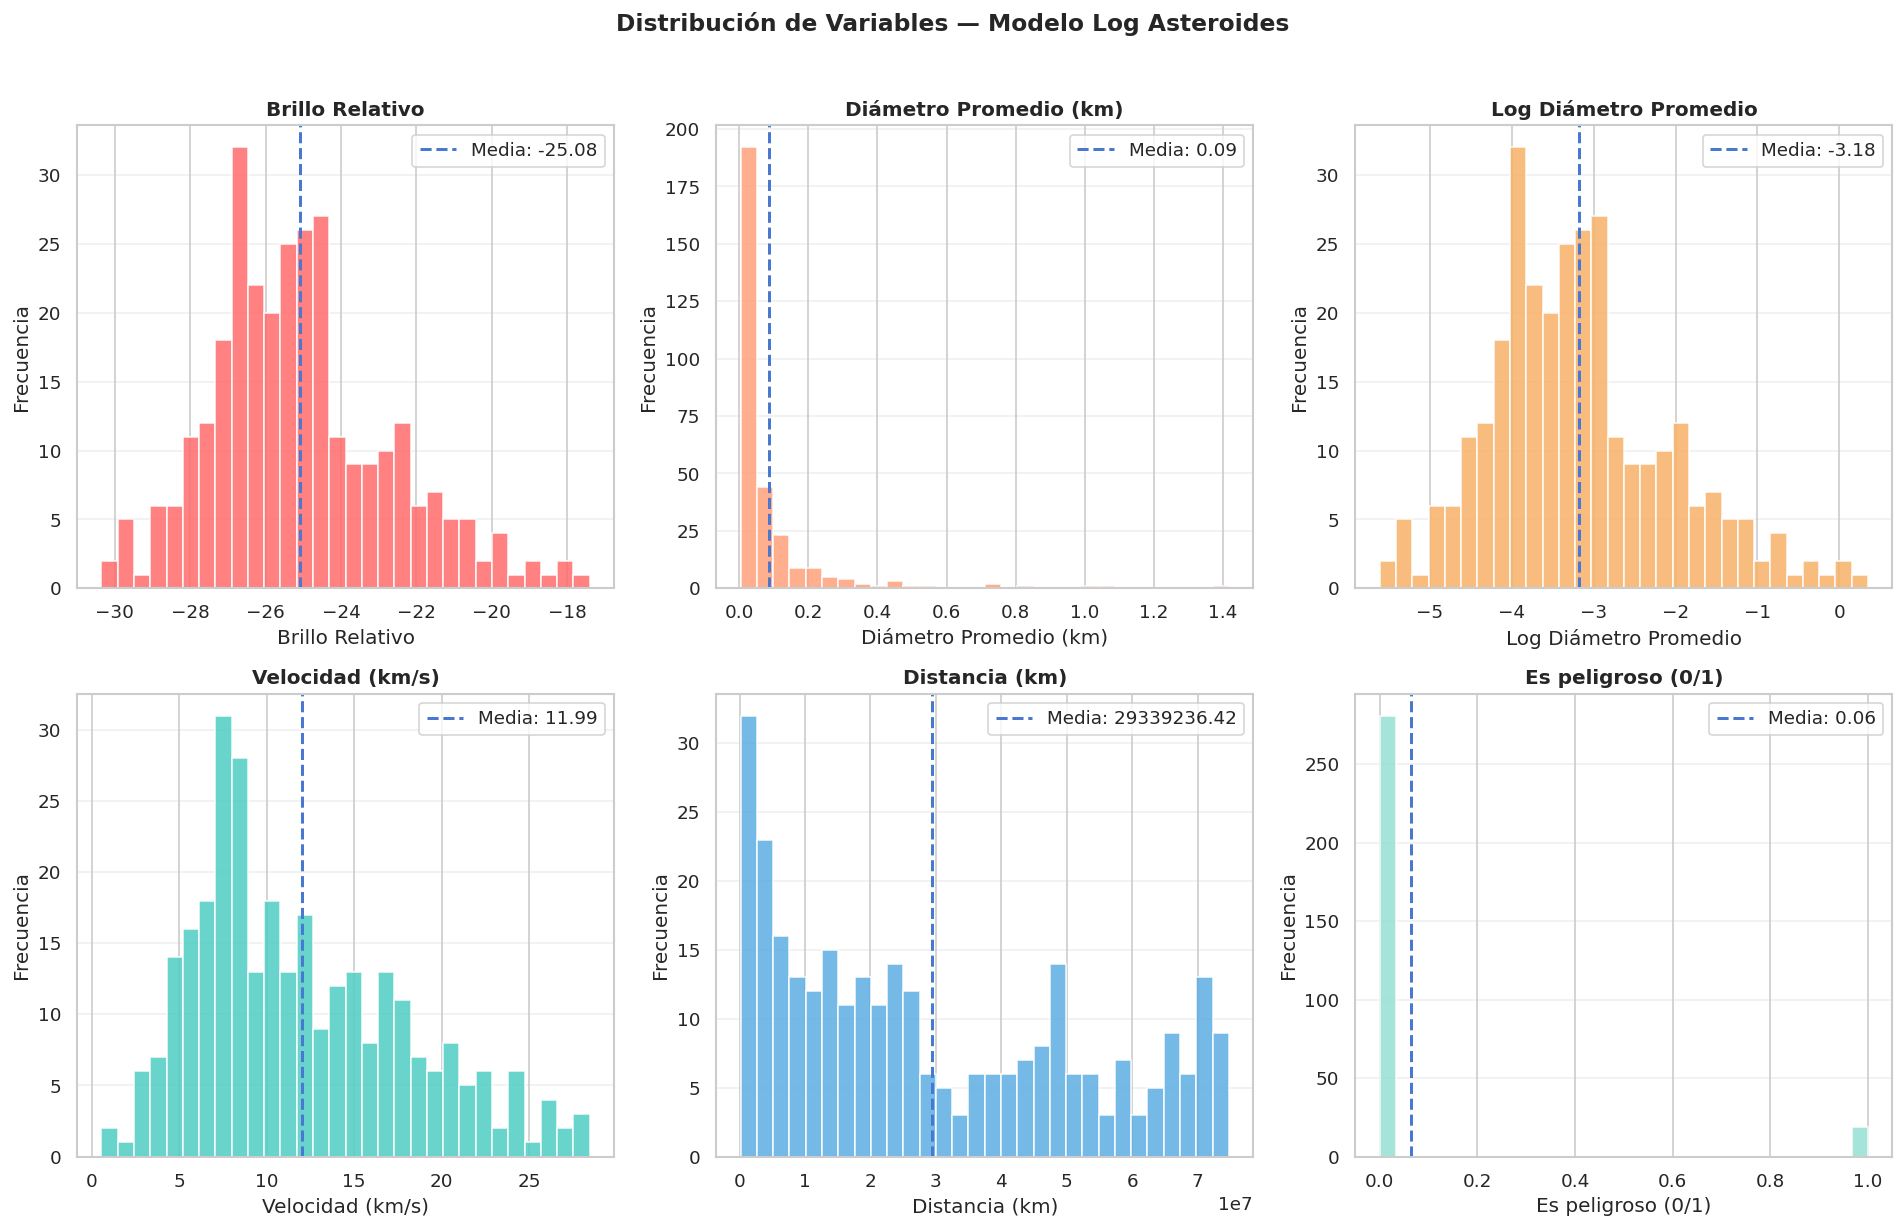

In [6]:
# ── CELDA 5: Histogramas de distribución (modelo log) ─────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables — Modelo Log Asteroides',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'brillo_relativo':        ('Brillo Relativo', '#ff6b6b'),
    'diametro_promedio_km':   ('Diámetro Promedio (km)', '#ffa07a'),
    'log_diametro_promedio':  ('Log Diámetro Promedio', '#f7b267'),
    'velocidad_km_s':         ('Velocidad (km/s)', '#4ecdc4'),
    'distancia_km':           ('Distancia (km)', '#5dade2'),
    'es_peligroso_num':       ('Es peligroso (0/1)', '#95e1d3')
}

# Convertimos es_peligroso a numérico (si no existe aún)
if 'es_peligroso_num' not in df.columns:
    df['es_peligroso_num'] = df['es_peligroso'].astype(int)

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    
    data = df[col]
    
    ax.hist(data, bins=30, edgecolor='white', alpha=0.85, color=color)
    
    media = data.mean()
    ax.axvline(media, linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

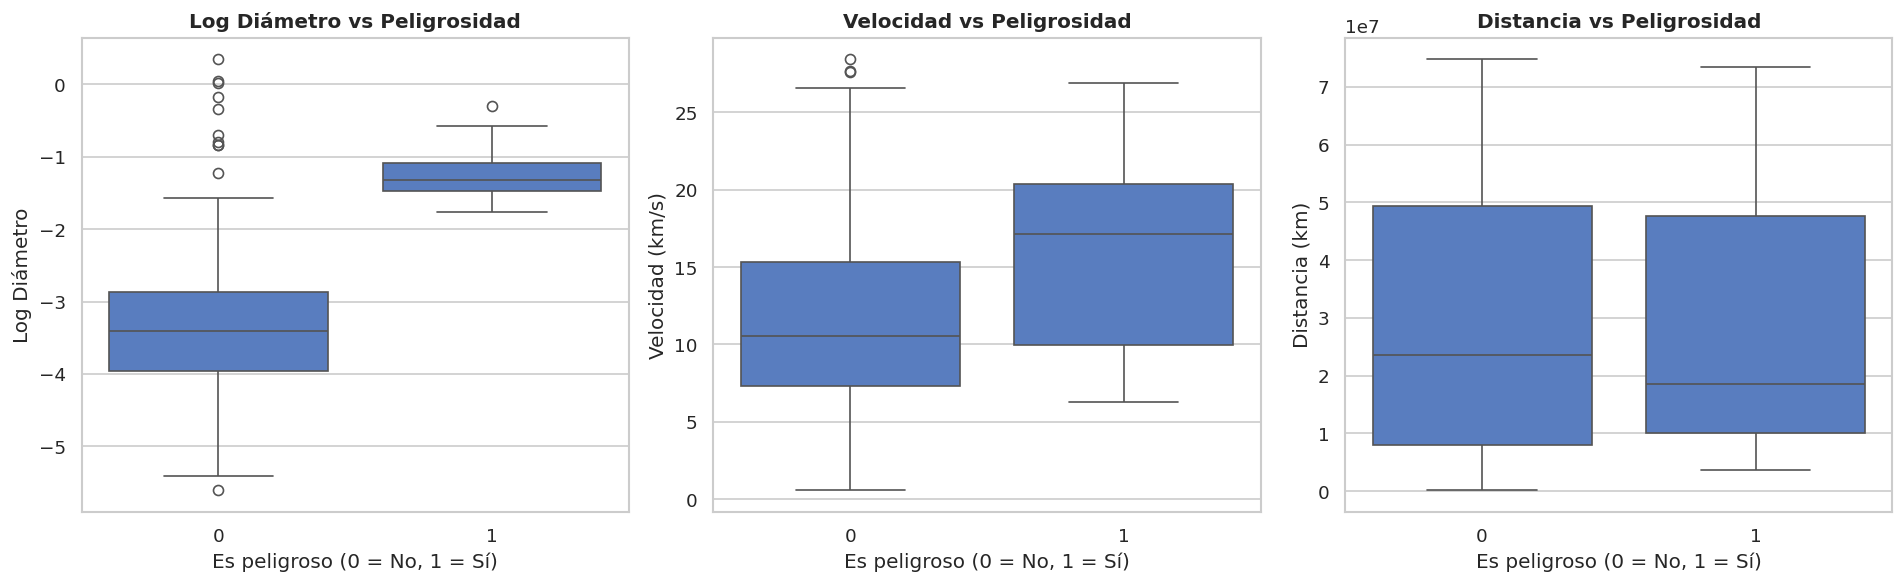

In [7]:
# ── CELDA 6: Boxplots por categoría (modelo log) ────────────

# Asegurar variable numérica
if 'es_peligroso_num' not in df.columns:
    df['es_peligroso_num'] = df['es_peligroso'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='es_peligroso_num', y='log_diametro_promedio',
            ax=axes[0])
axes[0].set_title('Log Diámetro vs Peligrosidad', fontweight='bold')
axes[0].set_xlabel('Es peligroso (0 = No, 1 = Sí)')
axes[0].set_ylabel('Log Diámetro')

sns.boxplot(data=df, x='es_peligroso_num', y='velocidad_km_s',
            ax=axes[1])
axes[1].set_title('Velocidad vs Peligrosidad', fontweight='bold')
axes[1].set_xlabel('Es peligroso (0 = No, 1 = Sí)')
axes[1].set_ylabel('Velocidad (km/s)')

sns.boxplot(data=df, x='es_peligroso_num', y='distancia_km',
            ax=axes[2])
axes[2].set_title('Distancia vs Peligrosidad', fontweight='bold')
axes[2].set_xlabel('Es peligroso (0 = No, 1 = Sí)')
axes[2].set_ylabel('Distancia (km)')

plt.tight_layout()
plt.show()

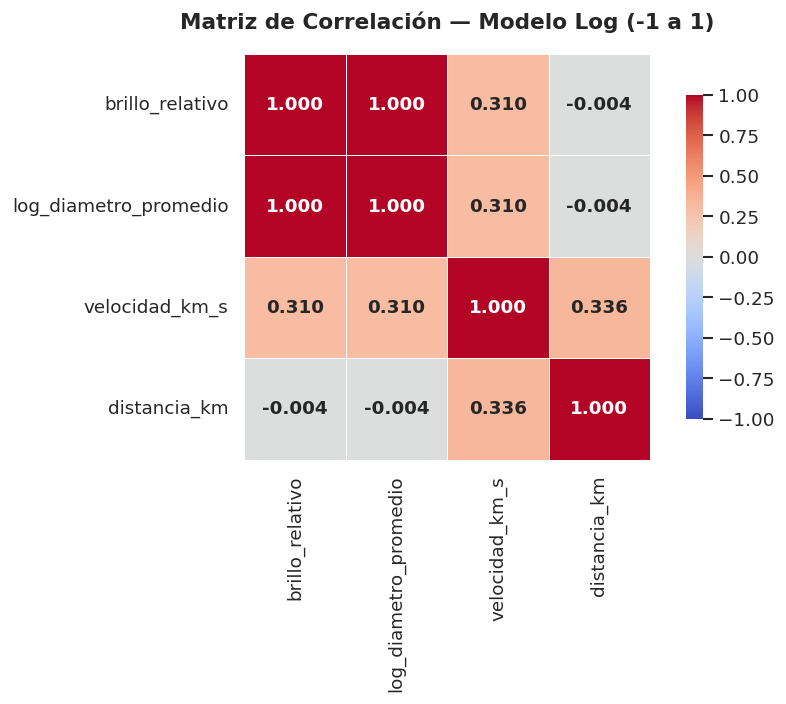


📊 Correlación con log_diametro_promedio:
brillo_relativo    1.0000
velocidad_km_s     0.3095
distancia_km      -0.0042
Name: log_diametro_promedio, dtype: float64


In [12]:
# ── CELDA 7: Matriz de correlación (modelo log) ──────────────

# 🔹 1. Variables para correlación (modelo log)
vars_modelo = [
    'brillo_relativo',
    'log_diametro_promedio',
    'velocidad_km_s',
    'distancia_km'
]

corr = df[vars_modelo].corr()

# 🔹 2. Heatmap con escala fija [-1, 1]
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Matriz de Correlación — Modelo Log (-1 a 1)',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# 🔹 3. Correlación con variable objetivo (log)
print("\n📊 Correlación con log_diametro_promedio:")
print(
    corr['log_diametro_promedio']
    .drop('log_diametro_promedio')
    .sort_values(ascending=False)
    .round(4)
)

In [15]:
df[['brillo_relativo', 'log_diametro_promedio']].corr()

,brillo_relativo,log_diametro_promedio
brillo_relativo,1.0,1.0
log_diametro_promedio,1.0,1.0
